# Model test & validation: LightGBM

Gradient-boosted tree ensemble -- same leaf-constant extrapolation limitation as Random Forest/Extra Trees, but built additively (each tree corrects the previous ensemble's residual) rather than by independent averaging. Tests whether this different construction changes the extrapolation failure mode.

In [1]:
import lightgbm as lgb

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.filterwarnings("ignore")

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
def r2(y_true, y_pred):
    return float(r2_score(y_true, y_pred))

df_raw = pd.read_csv("../chf_long_clean.csv")
df = df_raw[df_raw.X != 1.0].reset_index(drop=True)
FEATURES = ["P", "G", "X"]
TARGET = "CHF"
sorted_P = sorted(df.P.unique())

# Split A (random, seed 0) -- quick interpolation check
X_all, y_all = df[FEATURES].values, df[TARGET].values
XtrA, XteA, ytrA, yteA = train_test_split(X_all, y_all, test_size=0.2, random_state=0)

# Split C (edge extrapolation) -- the honest test
train_dfC = df[df.P <= 16000].reset_index(drop=True)
test_dfC = df[df.P >= 17000].reset_index(drop=True)
XtrC, ytrC = train_dfC[FEATURES].values, train_dfC[TARGET].values
XteC, yteC = test_dfC[FEATURES].values, test_dfC[TARGET].values

print(f"Split A: {len(XtrA)} train / {len(XteA)} test")
print(f"Split C: {len(XtrC)} train / {len(XteC)} test")


Split A: 8870 train / 2218 test
Split C: 8778 train / 2310 test


## Fit on Split A (interpolation) and Split C (extrapolation)

In [2]:

model_A = lgb.LGBMRegressor(n_estimators=400, random_state=0, n_jobs=-1, verbosity=-1).fit(XtrA, ytrA)
predA = model_A.predict(XteA)
print(f"Split A: R2={r2(yteA, predA):.4f}, MAPE={mape(yteA, predA):.2f}%")

model_C = lgb.LGBMRegressor(n_estimators=400, random_state=0, n_jobs=-1, verbosity=-1).fit(XtrC, ytrC)
predC = model_C.predict(XteC)
print(f"Split C: R2={r2(yteC, predC):.4f}, MAPE={mape(yteC, predC):.2f}%")


Split A: R2=0.9991, MAPE=6.77%


Split C: R2=0.4257, MAPE=46.38%


## Edge-case tests

Same far-extrapolation plateau probe as the bagged tree ensembles -- confirms that additive boosting has the identical structural limitation, since its final prediction is still a sum of leaf constants, each bounded by its own tree's training-range leaves.

In [3]:

G_fixed, X_fixed = 2000.0, 0.0
p_probe = np.array([15000, 16000, 17000, 19000, 21000, 30000, 60000, 120000], dtype=float)
probe_pts = np.column_stack([p_probe, np.full_like(p_probe, G_fixed), np.full_like(p_probe, X_fixed)])
probe_pred = model_C.predict(probe_pts)
print("Prediction vs. probe pressure (G=2000, X=0.0), training P maxes out at 16000:")
for p, pred in zip(p_probe, probe_pred):
    print(f"  P={p:>7.0f} kPa -> predicted CHF={pred:.1f}")
print(f"\nPredictions beyond ~21000 kPa are (near-)identical: "
      f"{'PASS' if np.allclose(probe_pred[-3:], probe_pred[-1], rtol=0.02) else 'FAIL'} "
      f"-- additive boosting shares the same leaf-constant extrapolation ceiling as "
      f"bagged trees, despite building the ensemble differently.")


Prediction vs. probe pressure (G=2000, X=0.0), training P maxes out at 16000:
  P=  15000 kPa -> predicted CHF=2459.8
  P=  16000 kPa -> predicted CHF=2320.1
  P=  17000 kPa -> predicted CHF=2320.1
  P=  19000 kPa -> predicted CHF=2320.1
  P=  21000 kPa -> predicted CHF=2320.1
  P=  30000 kPa -> predicted CHF=2320.1
  P=  60000 kPa -> predicted CHF=2320.1
  P= 120000 kPa -> predicted CHF=2320.1

Predictions beyond ~21000 kPa are (near-)identical: PASS -- additive boosting shares the same leaf-constant extrapolation ceiling as bagged trees, despite building the ensemble differently.


## Diagnostic plot

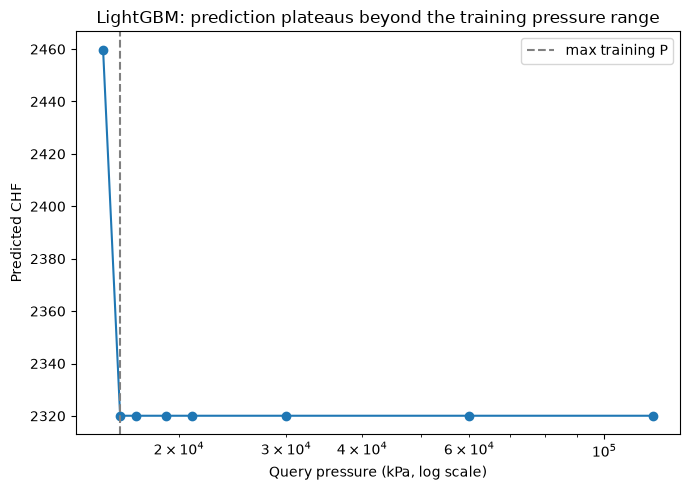

In [4]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(p_probe, probe_pred, "o-")
ax.axvline(16000, color="gray", linestyle="--", label="max training P")
ax.set_xscale("log")
ax.set_xlabel("Query pressure (kPa, log scale)")
ax.set_ylabel("Predicted CHF")
ax.set_title(f"LightGBM: prediction plateaus beyond the training pressure range")
ax.legend()
plt.tight_layout()
plt.savefig("../results/model_tests_lightgbm.png", dpi=100)
plt.show()
